# Initial Imports and constants

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import jax.numpy as jnp
import os


In [3]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/k2-19-project/data


In [4]:
### Define data directory
# data_dir = "/Users/pentrican10/Projects/Data/k2-19-data"

TESS_offset = 2457000
petigura_offset = 2454833

### switch to mask out transits
mask_transits = True

### set range for search: [#hours] * [days per hour]
ttv_hour = 2* 0.0416667 # 1 hour to days

In [28]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

# BLS Fit

In [5]:
# Download the light curve data
lc = lk.search_lightcurve("K2-19",author = 'SPOC').download_all()
print(lc)


LightCurveCollection of 3 objects:
    0: <TessLightCurve LABEL="TIC 281885301" SECTOR=45 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 281885301" SECTOR=46 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 281885301" SECTOR=72 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


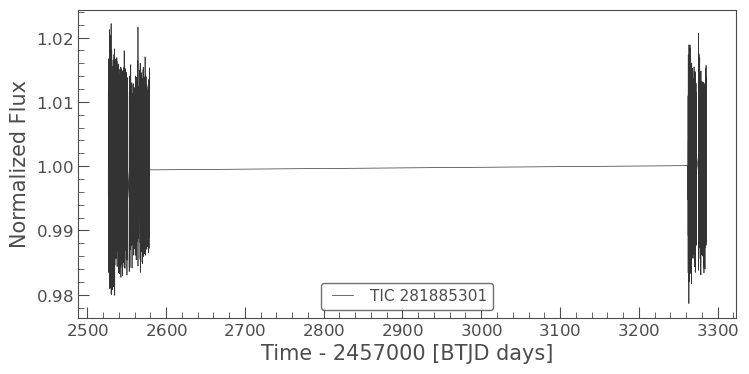

In [6]:
# Flatten the light curve
lc = lc.stitch().flatten(window_length=901).remove_outliers()
lc.plot()
plt.show()
time = lc.time
flux=lc.flux
flux_err = lc.flux_err

## Planet b BLS

In [7]:
### perform periodigram for planet b
### Create array of periods to search
period = np.linspace(1, 20, 10000)

### Create a BLSPeriodogram
bls = lc.to_periodogram(method='bls', period=period, frequency_factor=500)
#bls.plot()

period_b_bls = bls.period_at_max_power.value
tc_b_bls = bls.transit_time_at_max_power.value
dur_b_bls = bls.duration_at_max_power.value

print(f'Period from BLS: {period_b_bls}')
print(f'TC from BLS: {tc_b_bls}')

Period from BLS: 7.9204920492049204
TC from BLS: 2530.2807708159753


In [8]:
# Create a cadence mask using the BLS parameters
planet_b_mask = bls.get_transit_mask(period=period_b_bls,
                                     transit_time=tc_b_bls,
                                     duration=dur_b_bls*1.5)

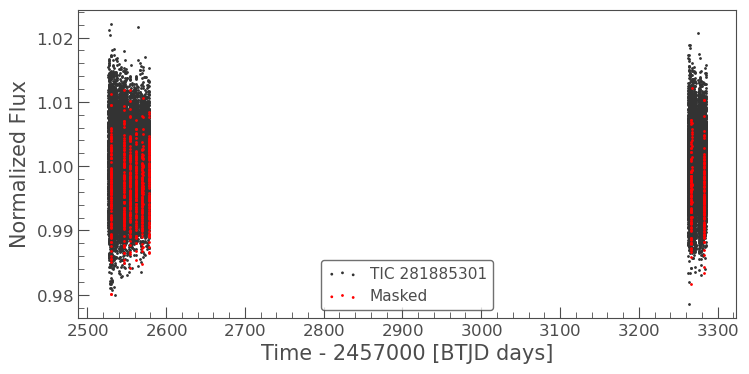

In [9]:
masked_lc_b = lc[~planet_b_mask]
ax = masked_lc_b.scatter();
lc[planet_b_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [10]:
# Create a BLS model using the BLS parameters
planet_b_model = bls.get_transit_model(period=period_b_bls,
                                       transit_time=tc_b_bls,
                                       duration=dur_b_bls)


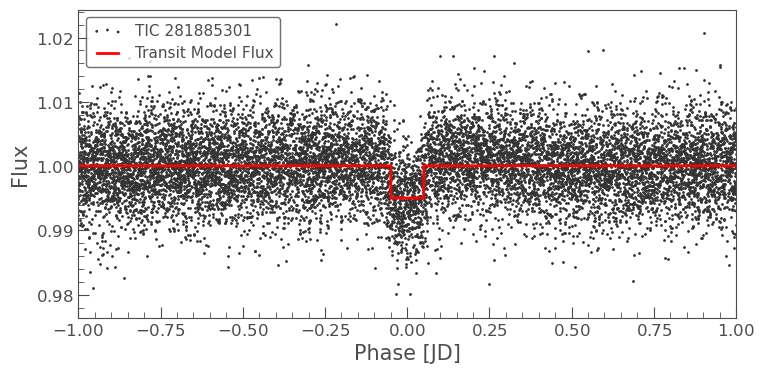

In [11]:
ax = lc.fold(period_b_bls, tc_b_bls).scatter()
planet_b_model.fold(period_b_bls, tc_b_bls).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## planet c BLS

In [18]:
### perform periodigram for planet c
### Create array of periods to search
period = np.linspace(11.6, 12.1, 10000)

### Create a BLSPeriodogram
bls_c = masked_lc_b.to_periodogram(method='bls', period=period, frequency_factor=500)
#bls.plot()

period_c_bls = bls_c.period_at_max_power.value
tc_c_bls = bls_c.transit_time_at_max_power.value
dur_c_bls = bls_c.duration_at_max_power.value

print(f'Period from BLS: {period_c_bls}')
print(f'TC from BLS: {tc_c_bls}')

Period from BLS: 11.912781278127813
TC from BLS: 2529.2807708159753


In [19]:
# Create a cadence mask using the BLS parameters
planet_c_mask = bls_c.get_transit_mask(period=period_c_bls,
                                     transit_time=tc_c_bls,
                                     duration=dur_c_bls*1.5)

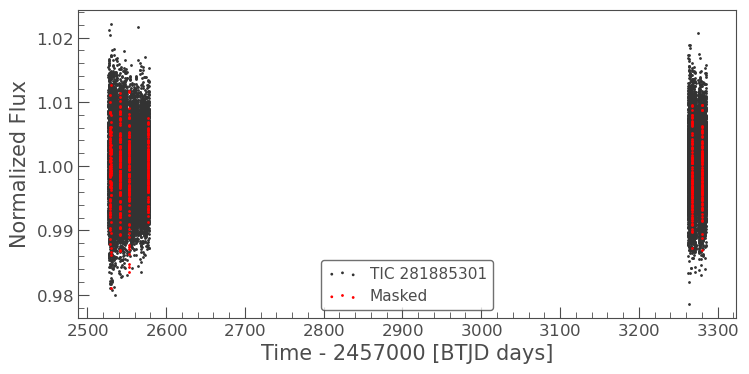

In [20]:
masked_lc_c = masked_lc_b[~planet_c_mask]
ax = masked_lc_c.scatter();
masked_lc_b[planet_c_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [21]:
# Create a BLS model using the BLS parameters
planet_c_model = bls.get_transit_model(period=period_c_bls,
                                       transit_time=tc_c_bls,
                                       duration=dur_c_bls)


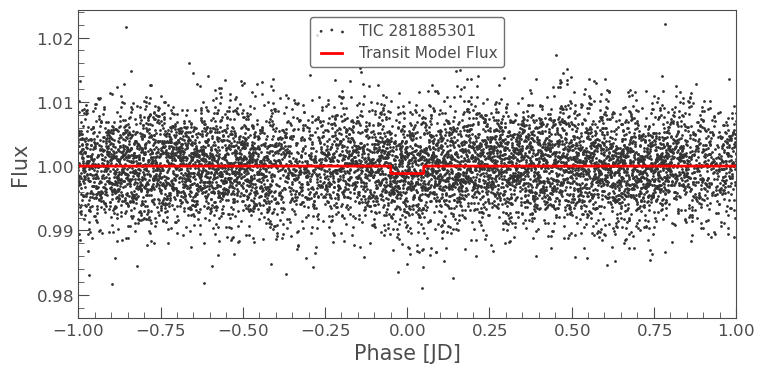

In [22]:
ax = masked_lc_b.fold(period_c_bls, tc_c_bls).scatter()
planet_c_model.fold(period_c_bls, tc_c_bls).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

In [ ]:
# Find all local minima (i.e., transit dips)
peaks_c, _ = find_peaks(-planet_c_model.flux.value, prominence=1e-5)
transit_times_2 = np.sort(planet_2_model.time.value[peaks_2])
fluxes_2 = planet_2_model.flux.value[peaks_2]

print("Planet 2 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_2)

In [30]:
# from petigura 2020
Tc_c = 2456853 - 2457000 # tc - TESS offset
P_c = 11.8993
T14_c = tc_c_bls #3.823 * 0.0416667  # from crossfield 2016


### Using BLS ephem

In [68]:
def bin_data(x, y, binsize):
    """Returns binned x, mean y in each bin"""
    bins = np.arange(x.min(), x.max() + binsize, binsize)
    digitized = np.digitize(x, bins)
    x_bin = np.array([x[digitized == i].mean() for i in range(1, len(bins)) if np.any(digitized == i)])
    y_bin = np.array([y[digitized == i].mean() for i in range(1, len(bins)) if np.any(digitized == i)])
    return x_bin, y_bin


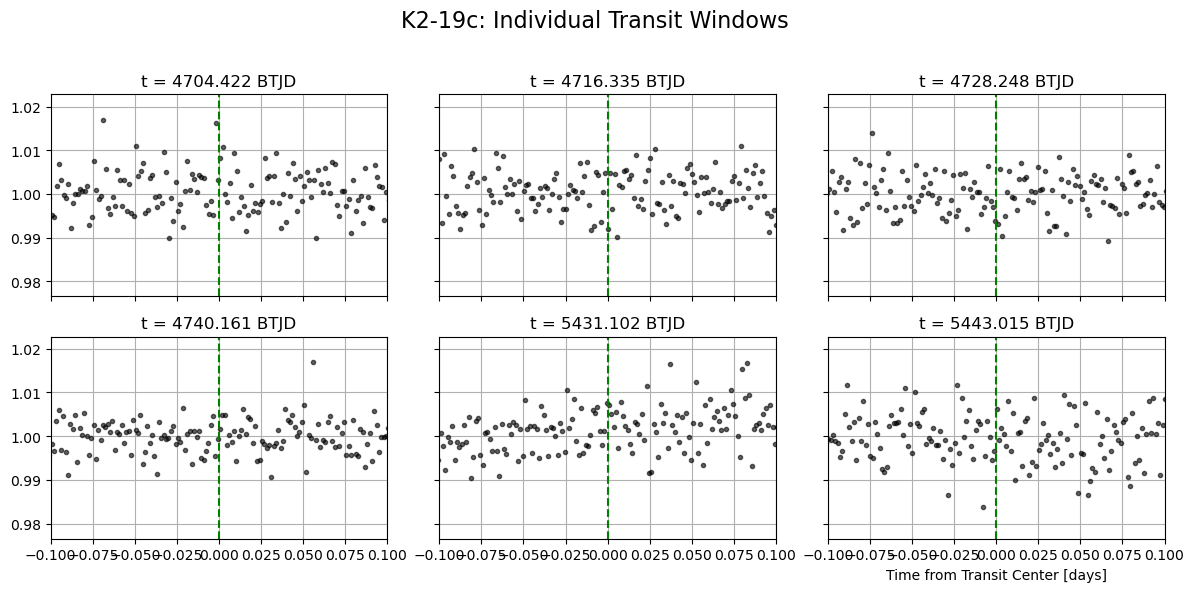

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Convert time to numpy array if needed
time = convert_time_t2p(lc.time.value)
flux = lc.flux
flux_err = lc.flux_err

# Ephemeris parameters
t0 = convert_time_t2p(period_c_bls) #convert_time_t2p(Tc_c)       # BTJD
period = period_c_bls #11.8993    # days
duration = dur_c_bls #0.159    # days

# Compute expected transit times
epoch_start = int(np.floor((time.min() - t0) / period))
epoch_end = int(np.ceil((time.max() - t0) / period))
epochs = np.arange(epoch_start, epoch_end + 1)
transit_times = t0 + epochs * period

# Store chunks with data
transit_chunks = []
transit_labels = []
for t_center in transit_times:
    mask = np.abs(time - t_center) < (duration * 8.5)
    if np.any(mask):
        dt = time[mask] - t_center
        f = flux[mask]
        transit_chunks.append((dt, f))
        transit_labels.append(f"t = {t_center:.3f} BTJD")

# Plot one subplot per transit
n = len(transit_chunks)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True, sharey=True)
axs = axs.flatten()

for i, ((dt, f), label) in enumerate(zip(transit_chunks, transit_labels)):
    axs[i].plot(dt, f, 'k.', alpha=0.6)
    axs[i].axvline(0, color='g', linestyle='--')
    axs[i].set_title(label)
    axs[i].set_xlim(-duration, duration)
    axs[i].grid(True)

# Hide unused subplots
for j in range(i+1, len(axs)):
    axs[j].axis('off')

fig.suptitle("K2-19c: Individual Transit Windows", fontsize=16)
plt.xlabel("Time from Transit Center [days]")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


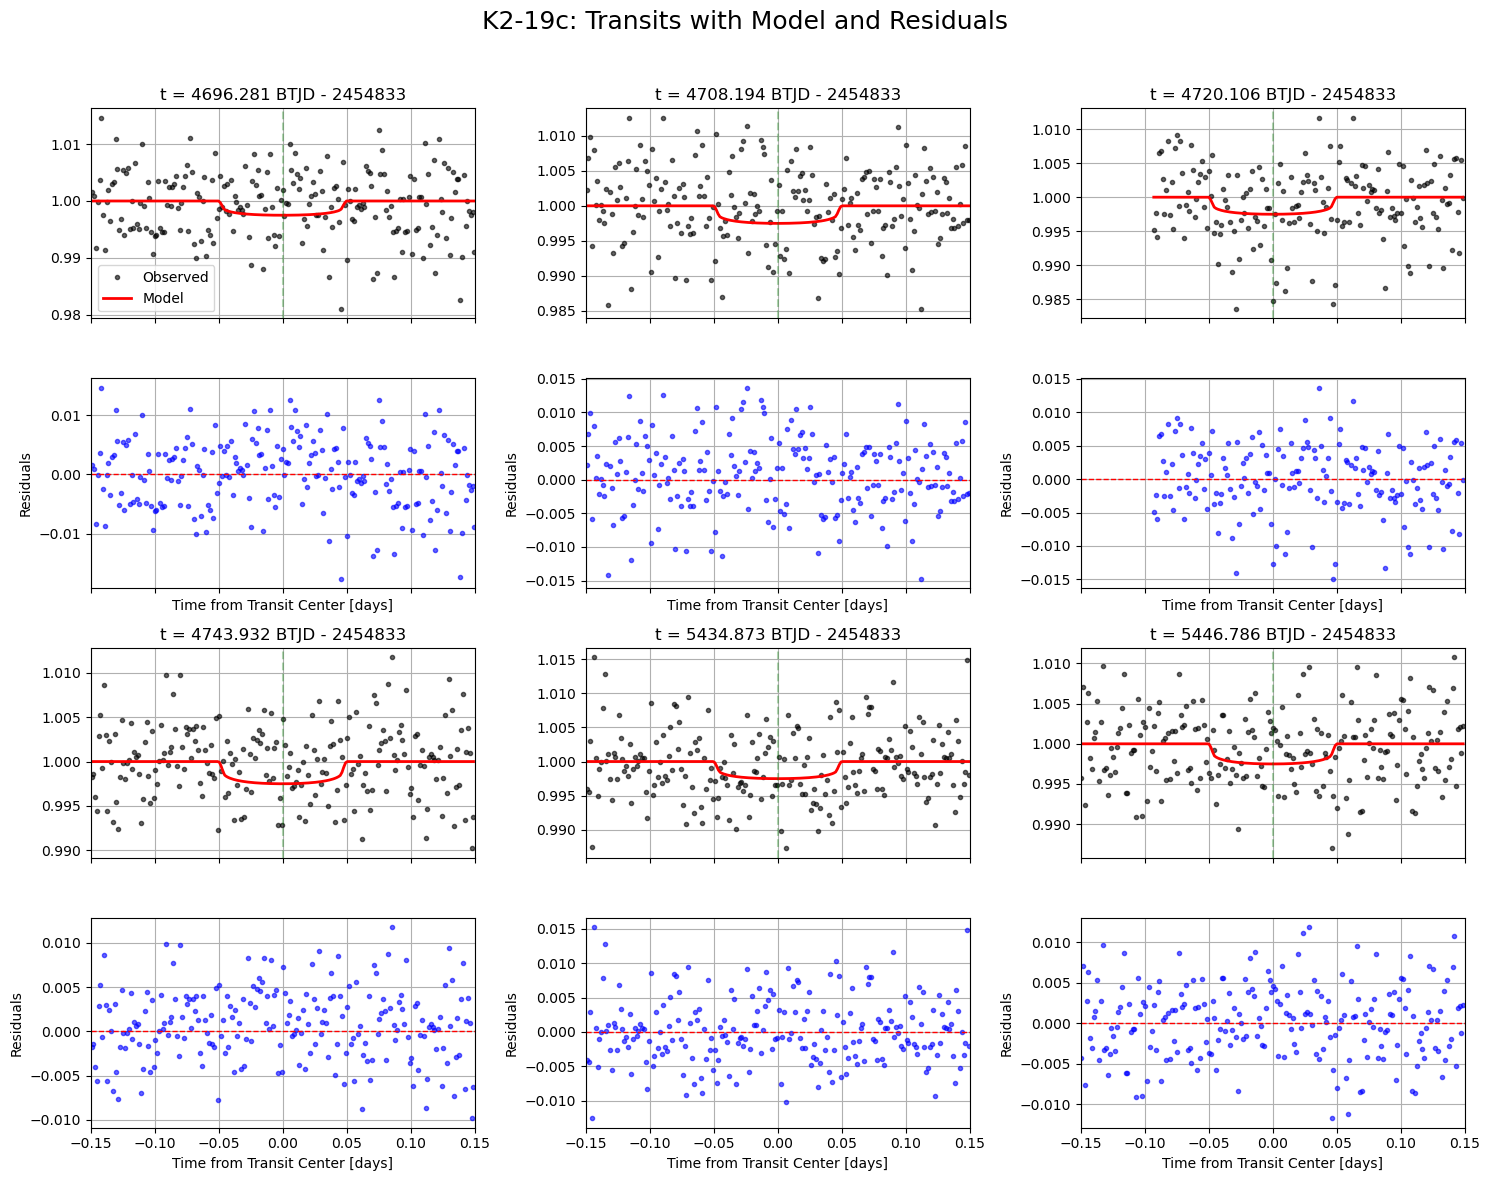

In [65]:
import matplotlib.gridspec as gridspec

# Ephemeris and lightcurve (assuming already loaded)
time = convert_time_t2p(lc.time.value)
flux = lc.flux

# Transit model parameters (update with your values!)
Tc_c = tc_c_bls #2456860 - 2457000
t0 = convert_time_t2p(Tc_c)       # BTJD
P_c = period_c_bls #7.9222    # days
T14_c = dur_c_bls #3.237  * 0.0416667  # days
rp_c = 0.0458
b_c = 0.17
q1_c = 0.4
q2_c = 0.3



# per_b = 7.9222
# rp_b = 0.0777
# T14_b = 3.237 * 0.0416667
# b_b = 0.17
# q1_b = 0.4
# q2_b = 0.3

# Model setup template
def make_model(t_center, time_segment):
    params = batman.TransitParams()
    params.t0 = t_center
    params.per = P_c
    params.rp = rp_c
    params.b = b_c
    params.T14 = T14_c
    params.u = [2 * np.sqrt(q1_c) * q2_c, np.sqrt(q1_c) * (1 - 2 * q2_c)]
    params.limb_dark = "quadratic"
    m = batman.TransitModel(params, time_segment)
    return m.light_curve(params)

# Find transit centers in range
epoch_start = int(np.floor((time.min() - t0) / P_c))
epoch_end = int(np.ceil((time.max() - t0) / P_c))
epochs = np.arange(epoch_start, epoch_end + 1)
transit_times = t0 + epochs * P_c

# Extract segments with data
transit_chunks = []
transit_labels = []
transit_models = []

for t_center in transit_times:
    mask = np.abs(time - t_center) < (T14_c * 1.5)
    if np.any(mask):
        t_seg = time[mask]
        f_seg = flux[mask]
        model_flux = make_model(t_center, t_seg)
        residuals = f_seg - model_flux
        
        transit_chunks.append((t_seg - t_center, f_seg, model_flux, residuals))
        transit_labels.append(f"t = {t_center:.3f} BTJD - {petigura_offset}")

# Plotting
n = len(transit_chunks)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axs = plt.subplots(nrows * 2, ncols, figsize=(5*ncols, 3*nrows*2), sharex='col')
axs = np.atleast_2d(axs)

for i, (dt, f, model, res) in enumerate(transit_chunks):
    row = (i // ncols) * 2
    col = i % ncols
    
    # Top plot: flux and model
    axs[row, col].plot(dt, f, 'k.', alpha=0.6, label='Observed')
    axs[row, col].plot(dt, model, 'r-', lw=2, label='Model')
    axs[row, col].axvline(0, color='g', linestyle='--', alpha=0.3)
    axs[row, col].set_title(transit_labels[i])
    axs[row, col].set_xlim(-T14_c*1.5, T14_c*1.5)
    axs[row, col].grid(True)
    if row == 0 and col == 0:
        axs[row, col].legend()

    # Bottom plot: residuals
    axs[row + 1, col].plot(dt, res, 'b.', alpha=0.6)
    axs[row + 1, col].axhline(0, color='red', linestyle='--', lw=1)
    axs[row + 1, col].set_xlim(-T14_c*1.5, T14_c*1.5)
    axs[row + 1, col].grid(True)
    axs[row + 1, col].set_xlabel("Time from Transit Center [days]")
    axs[row + 1, col].set_ylabel("Residuals")

# Hide unused subplots
total_plots = nrows * ncols
for j in range(n, total_plots):
    axs[(j // ncols)*2, j % ncols].axis('off')
    axs[(j // ncols)*2 + 1, j % ncols].axis('off')

fig.suptitle("K2-19c: Transits with Model and Residuals", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# for i, (dt, f, model) in enumerate(transit_chunks):
#     axs[i].plot(dt, f, 'k.', alpha=0.6, label='Observed')
#     axs[i].plot(dt, model, 'r-', lw=2, label='Model')
#     axs[i].axvline(0, color='g', linestyle='--', alpha=0.3)
#     axs[i].set_title(transit_labels[i])
#     axs[i].set_xlim(-T14_c*1.5, T14_c*1.5)
#     axs[i].grid(True)
#     if i == 0:
#         axs[i].legend()

# # Hide unused subplots
# for j in range(i+1, len(axs)):
#     axs[j].axis('off')

# fig.suptitle("K2-19c: Transits with Model Overlays", fontsize=16)
# plt.xlabel("Time from Transit Center [days]")
# plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show()


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_15405/3992791192.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


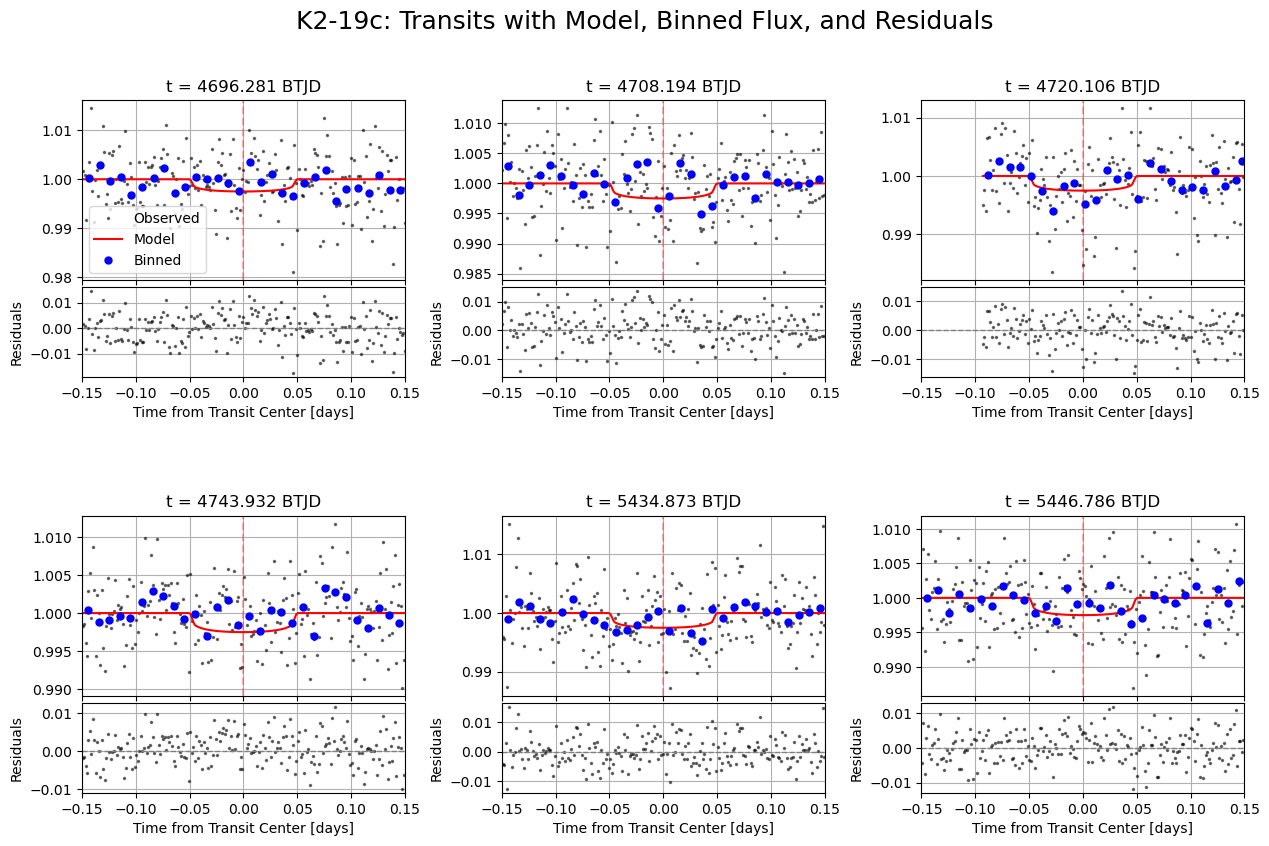

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import batman

# --- Light curve and transit parameters ---
# Ephemeris and lightcurve (assuming already loaded)
time = convert_time_t2p(lc.time.value)
flux = lc.flux

# Transit model parameters (update with your values!)
Tc_c = tc_c_bls #2456860 - 2457000
t0 = convert_time_t2p(Tc_c)       # BTJD
P_c = period_c_bls #7.9222    # days
T14_c = dur_c_bls #3.237  * 0.0416667  # days
rp_c = 0.0458
b_c = 0.17
q1_c = 0.4
q2_c = 0.3


# Model setup template
def make_model(t_center, time_segment):
    params = batman.TransitParams()
    params.t0 = t_center
    params.per = P_c
    params.rp = rp_c
    params.b = b_c
    params.T14 = T14_c
    params.u = [2 * np.sqrt(q1_c) * q2_c, np.sqrt(q1_c) * (1 - 2 * q2_c)]
    params.limb_dark = "quadratic"
    m = batman.TransitModel(params, time_segment)
    return m.light_curve(params)

# --- Compute expected transits ---
epoch_start = int(np.floor((time.min() - t0) / P_c))
epoch_end = int(np.ceil((time.max() - t0) / P_c))
epochs = np.arange(epoch_start, epoch_end + 1)
transit_times = t0 + epochs * P_c

# --- Collect segments ---
chunks = []
for t_center in transit_times:
    mask = np.abs(time - t_center) < (T14_c * 1.5)
    if np.any(mask):
        t_seg = time[mask]
        f_seg = flux[mask]
        model_flux = make_model(t_center, t_seg)
        residuals = f_seg - model_flux
        dt = t_seg - t_center
        chunks.append((dt, f_seg, model_flux, residuals, t_center))

# --- Plotting layout ---
n = len(chunks)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig = plt.figure(figsize=(5 * ncols, 3 * nrows * 1.5))
outer = gridspec.GridSpec(nrows, ncols, wspace=0.3, hspace=0.5)

for i, (dt, f, model, res, t_center) in enumerate(chunks):
    row = i // ncols
    col = i % ncols
    inner = gridspec.GridSpecFromSubplotSpec(2, 1,
        subplot_spec=outer[row, col], height_ratios=[2, 1], hspace=0.05)

    # Top: flux and model
    ax_flux = plt.Subplot(fig, inner[0])
    ax_flux.plot(dt, f, 'k.', alpha=0.5, markersize=3, label='Observed')
    ax_flux.plot(dt, model, 'r-', lw=1.5, label='Model')

    # Bin and overlay binned points
    dt_bin, f_bin = bin_data(dt, f, binsize=0.01)  # bin size in days
    ax_flux.plot(dt_bin, f_bin, 'bo', markersize=5, label='Binned')

    ax_flux.axvline(0, color='red', linestyle='--', alpha=0.3)
    ax_flux.set_xlim(-T14_c*1.5, T14_c*1.5)
    ax_flux.set_title(f"t = {t_center:.3f} BTJD")
    ax_flux.tick_params(labelbottom=False)
    ax_flux.grid(True)
    if i == 0:
        ax_flux.legend(loc='best')
    fig.add_subplot(ax_flux)

    # Bottom: residuals
    ax_resid = plt.Subplot(fig, inner[1])
    ax_resid.plot(dt, res, 'k.', alpha=0.5, markersize=3)
    ax_resid.axhline(0, color='gray', linestyle='--', lw=1)
    ax_resid.set_xlim(-T14_c*1.5, T14_c*1.5)
    ax_resid.set_xlabel("Time from Transit Center [days]")
    ax_resid.set_ylabel("Residuals")
    ax_resid.grid(True)
    fig.add_subplot(ax_resid)

fig.suptitle("K2-19c: Transits with Model, Binned Flux, and Residuals", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


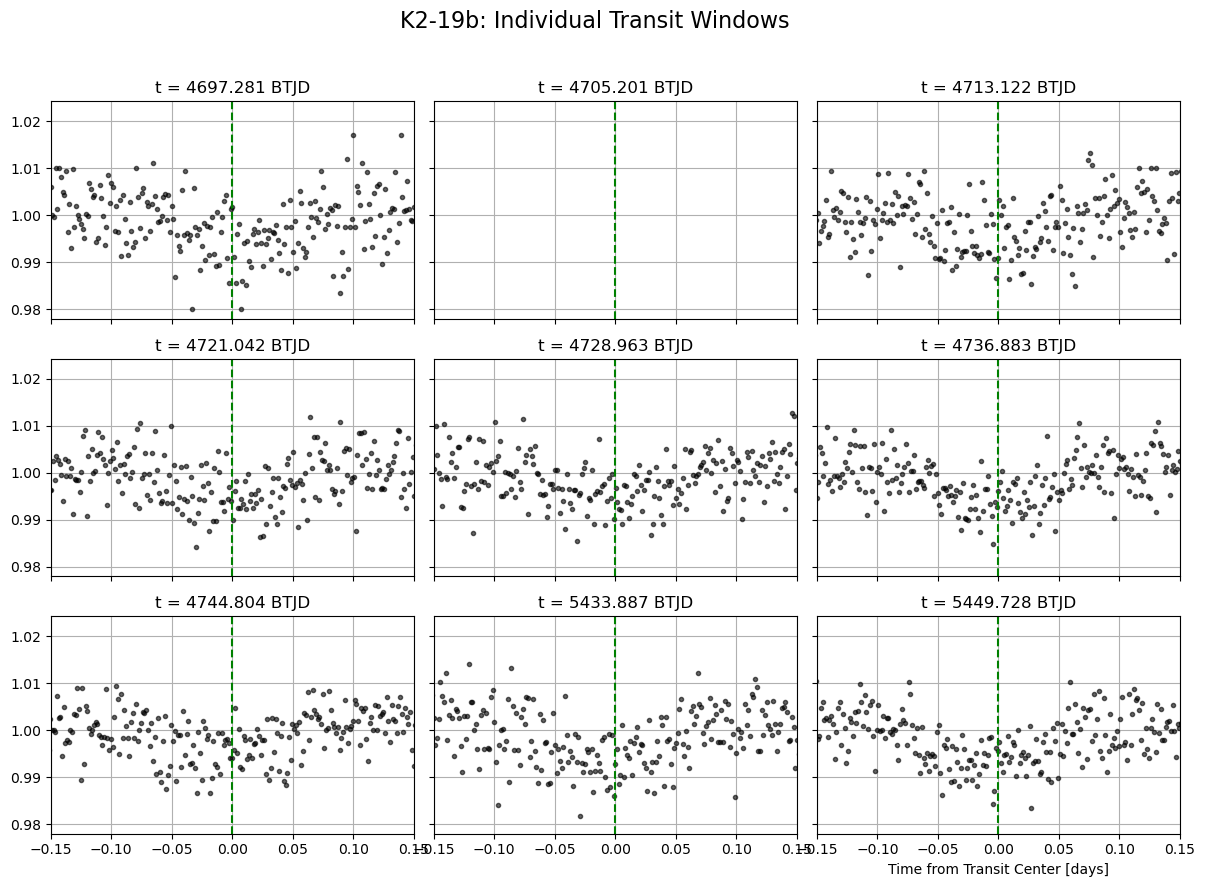

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Convert time to numpy array if needed
time = convert_time_t2p(lc.time.value)
flux = lc.flux
flux_err = lc.flux_err

# Ephemeris parameters
Tc_b = tc_b_bls #2456860 - 2457000
t0 = convert_time_t2p(Tc_b)       # BTJD
period = period_b_bls #7.9222    # days
duration = dur_b_bls #3.237  * 0.0416667  # days

# Compute expected transit times
epoch_start = int(np.floor((time.min() - t0) / period))
epoch_end = int(np.ceil((time.max() - t0) / period))
epochs = np.arange(epoch_start, epoch_end + 1)
transit_times = t0 + epochs * period

# Store chunks with data
transit_chunks = []
transit_labels = []
for t_center in transit_times:
    mask = np.abs(time - t_center) < (duration * 4.5)
    if np.any(mask):
        dt = time[mask] - t_center
        f = flux[mask]
        transit_chunks.append((dt, f))
        transit_labels.append(f"t = {t_center:.3f} BTJD")

# Plot one subplot per transit
n = len(transit_chunks)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True, sharey=True)
axs = axs.flatten()

for i, ((dt, f), label) in enumerate(zip(transit_chunks, transit_labels)):
    axs[i].plot(dt, f, 'k.', alpha=0.6)
    axs[i].axvline(0, color='g', linestyle='--')
    axs[i].set_title(label)
    axs[i].set_xlim(-duration*1.5, duration*1.5)
    axs[i].grid(True)

# Hide unused subplots
for j in range(i+1, len(axs)):
    axs[j].axis('off')

fig.suptitle("K2-19b: Individual Transit Windows", fontsize=16)
plt.xlabel("Time from Transit Center [days]")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


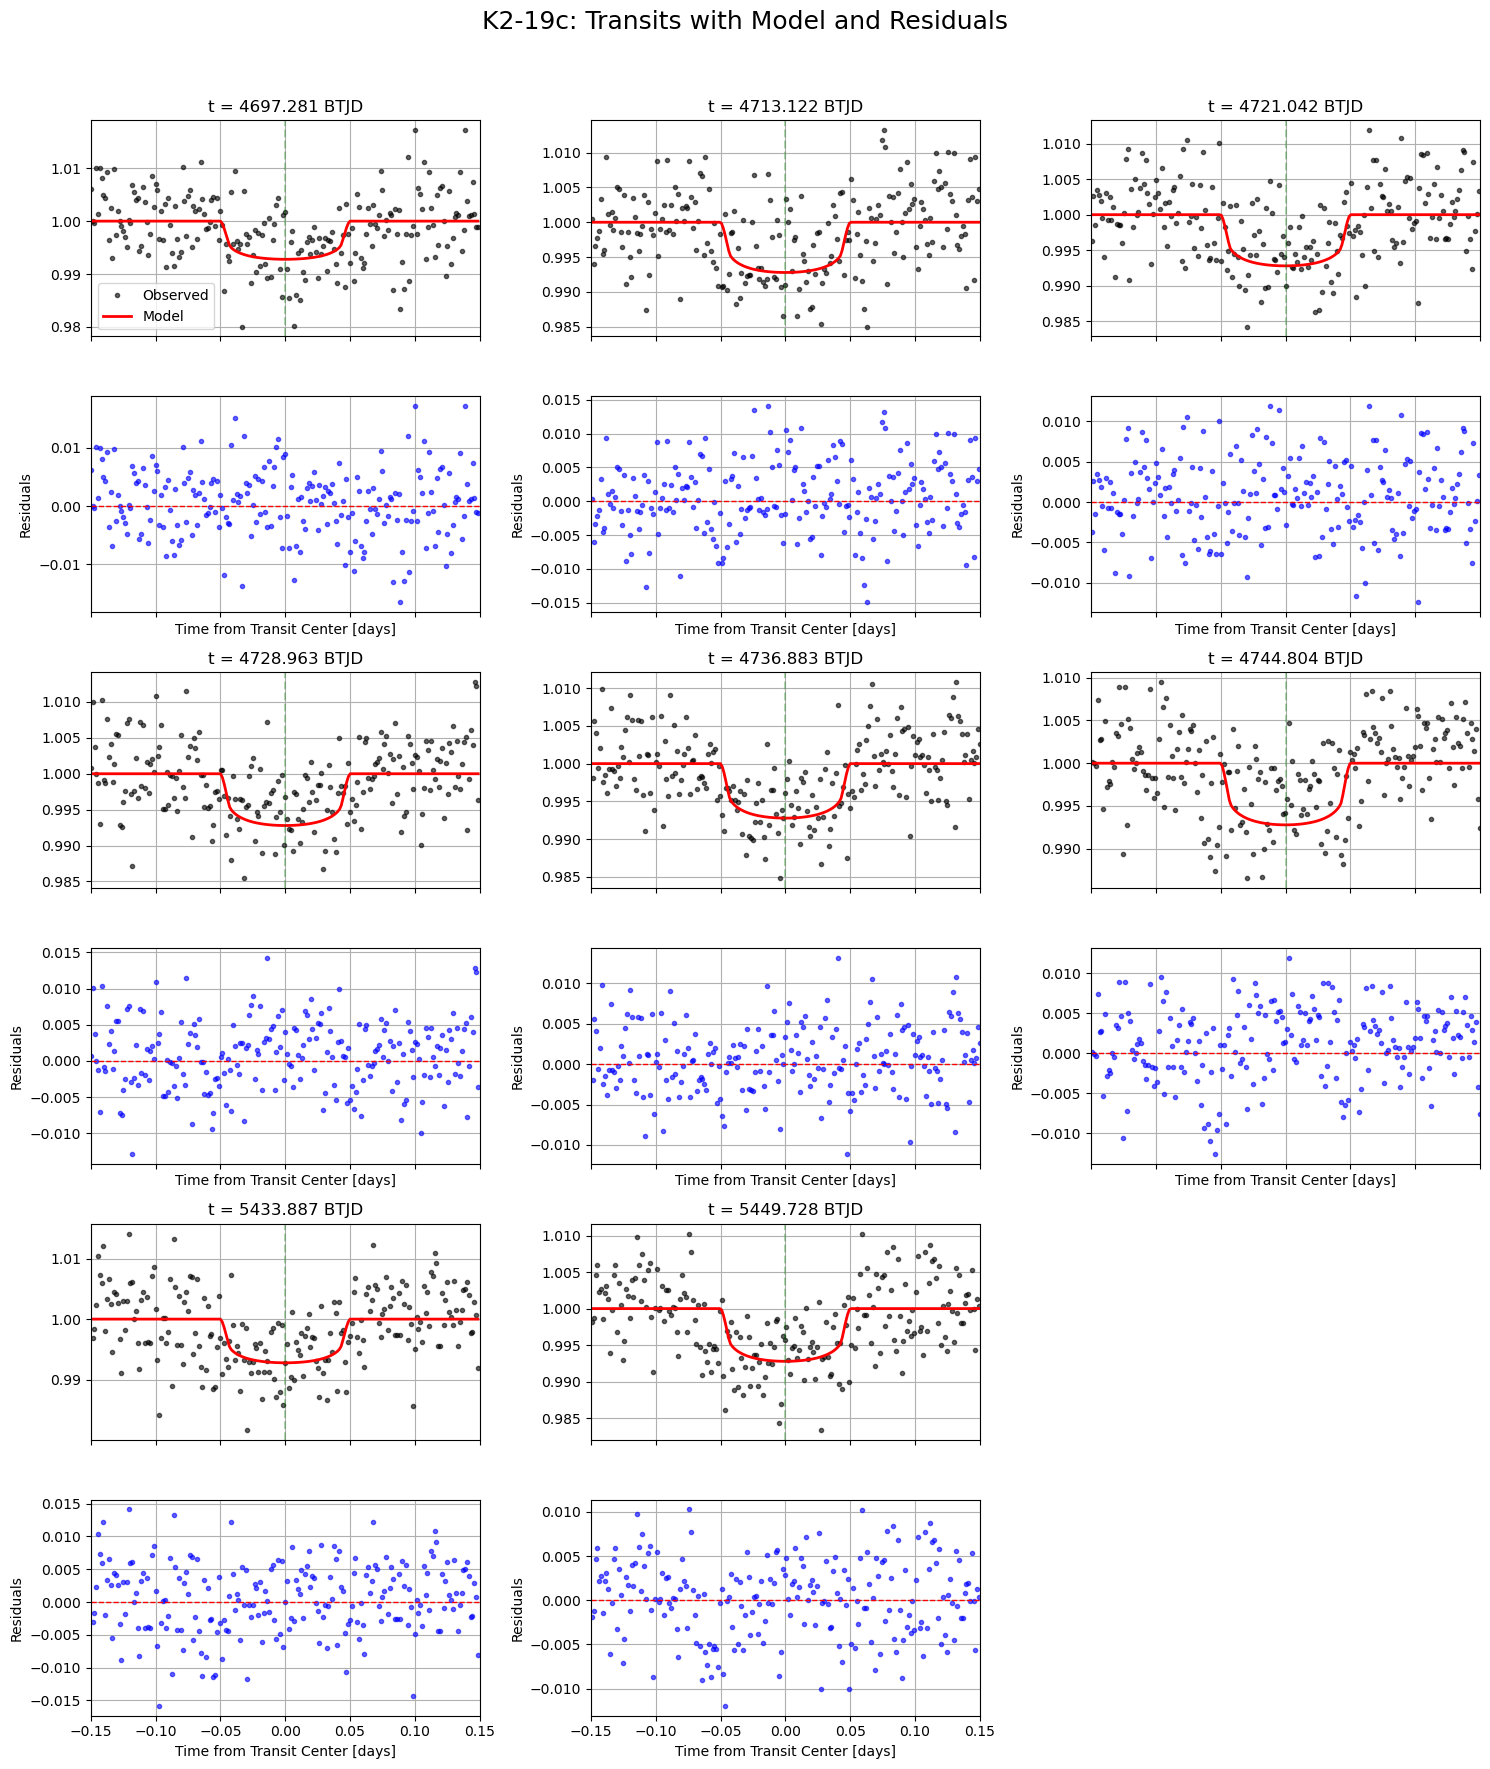

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import batman

# Ephemeris and lightcurve (assuming already loaded)
time = convert_time_t2p(lc.time.value)
flux = lc.flux

# Transit model parameters (update with your values!)
Tc_b = tc_b_bls #2456860 - 2457000
t0 = convert_time_t2p(Tc_b)       # BTJD
P_b = period_b_bls #7.9222    # days
T14_b = dur_b_bls #3.237  * 0.0416667  # days
rp_b = 0.0777
b_b = 0.17
q1_b = 0.4
q2_b = 0.3



# per_b = 7.9222
# rp_b = 0.0777
# T14_b = 3.237 * 0.0416667
# b_b = 0.17
# q1_b = 0.4
# q2_b = 0.3

# Model setup template
def make_model(t_center, time_segment):
    params = batman.TransitParams()
    params.t0 = t_center
    params.per = P_b
    params.rp = rp_b
    params.b = b_b
    params.T14 = T14_b
    params.u = [2 * np.sqrt(q1_b) * q2_b, np.sqrt(q1_b) * (1 - 2 * q2_b)]
    params.limb_dark = "quadratic"
    m = batman.TransitModel(params, time_segment)
    return m.light_curve(params)

# Find transit centers in range
epoch_start = int(np.floor((time.min() - t0) / P_b))
epoch_end = int(np.ceil((time.max() - t0) / P_b))
epochs = np.arange(epoch_start, epoch_end + 1)
transit_times = t0 + epochs * P_b

# Extract segments with data
transit_chunks = []
transit_labels = []
transit_models = []

for t_center in transit_times:
    mask = np.abs(time - t_center) < (T14_b * 1.5)
    if np.any(mask):
        t_seg = time[mask]
        f_seg = flux[mask]
        model_flux = make_model(t_center, t_seg)
        residuals = f_seg - model_flux
        
        transit_chunks.append((t_seg - t_center, f_seg, model_flux, residuals))
        transit_labels.append(f"t = {t_center:.3f} BTJD")

# Plotting
n = len(transit_chunks)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axs = plt.subplots(nrows * 2, ncols, figsize=(5*ncols, 3*nrows*2), sharex='col')
axs = np.atleast_2d(axs)

for i, (dt, f, model, res) in enumerate(transit_chunks):
    row = (i // ncols) * 2
    col = i % ncols
    
    # Top plot: flux and model
    axs[row, col].plot(dt, f, 'k.', alpha=0.6, label='Observed')
    axs[row, col].plot(dt, model, 'r-', lw=2, label='Model')
    axs[row, col].axvline(0, color='g', linestyle='--', alpha=0.3)
    axs[row, col].set_title(transit_labels[i])
    axs[row, col].set_xlim(-T14_b*1.5, T14_b*1.5)
    axs[row, col].grid(True)
    if row == 0 and col == 0:
        axs[row, col].legend()

    # Bottom plot: residuals
    axs[row + 1, col].plot(dt, res, 'b.', alpha=0.6)
    axs[row + 1, col].axhline(0, color='red', linestyle='--', lw=1)
    axs[row + 1, col].set_xlim(-T14_b*1.5, T14_b*1.5)
    axs[row + 1, col].grid(True)
    axs[row + 1, col].set_xlabel("Time from Transit Center [days]")
    axs[row + 1, col].set_ylabel("Residuals")

# Hide unused subplots
total_plots = nrows * ncols
for j in range(n, total_plots):
    axs[(j // ncols)*2, j % ncols].axis('off')
    axs[(j // ncols)*2 + 1, j % ncols].axis('off')

fig.suptitle("K2-19c: Transits with Model and Residuals", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



# fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True, sharey=True)
# axs = axs.flatten()

# for i, (dt, f, model) in enumerate(transit_chunks):
#     axs[i].plot(dt, f, 'k.', alpha=0.6, label='Observed')
#     axs[i].plot(dt, model, 'r-', lw=2, label='Model')
#     axs[i].axvline(0, color='g', linestyle='--', alpha=0.3)
#     axs[i].set_title(transit_labels[i])
#     axs[i].set_xlim(-T14_b*1.5, T14_b*1.5)
#     axs[i].grid(True)
#     if i == 0:
#         axs[i].legend()

# # Hide unused subplots
# for j in range(i+1, len(axs)):
#     axs[j].axis('off')

# fig.suptitle("K2-19b: Transits with Model Overlays", fontsize=16)
# plt.xlabel("Time from Transit Center [days]")
# plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show()


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_15405/3389365034.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


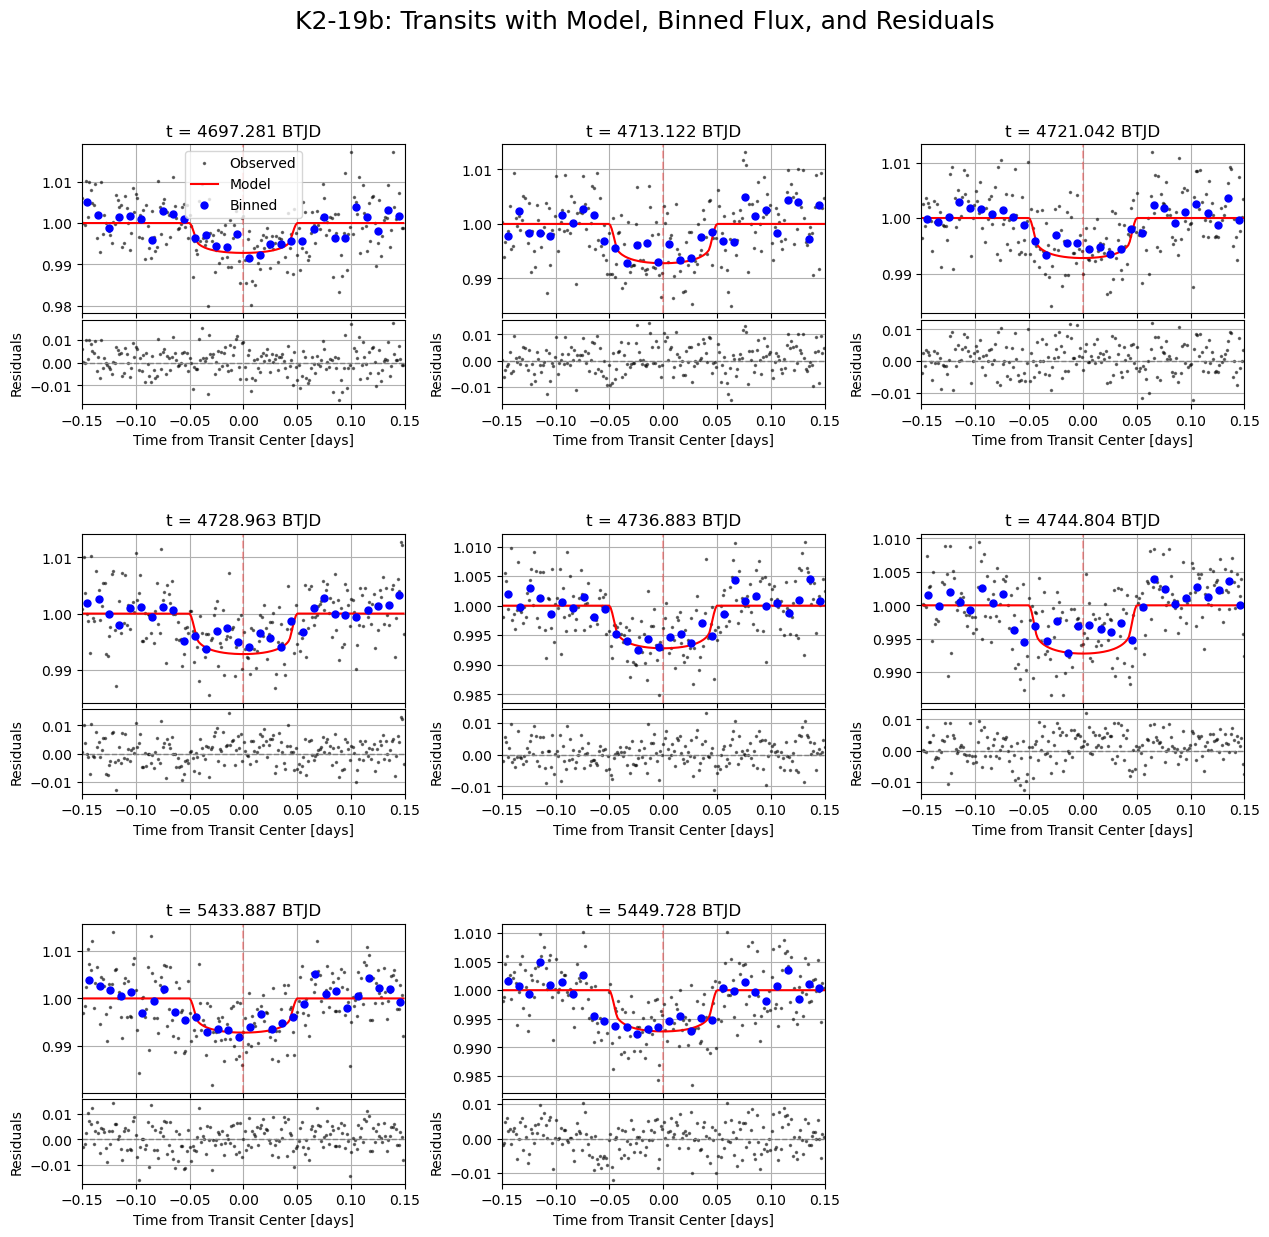

In [75]:
# Ephemeris and lightcurve (assuming already loaded)
time = convert_time_t2p(lc.time.value)
flux = lc.flux

# Transit model parameters (update with your values!)
Tc_b = tc_b_bls #2456860 - 2457000
t0 = convert_time_t2p(Tc_b)       # BTJD
P_b = period_b_bls #7.9222    # days
T14_b = dur_b_bls #3.237  * 0.0416667  # days
rp_b = 0.0777
b_b = 0.17
q1_b = 0.4
q2_b = 0.3



# Model setup template
def make_model(t_center, time_segment):
    params = batman.TransitParams()
    params.t0 = t_center
    params.per = P_b
    params.rp = rp_b
    params.b = b_b
    params.T14 = T14_b
    params.u = [2 * np.sqrt(q1_b) * q2_b, np.sqrt(q1_b) * (1 - 2 * q2_b)]
    params.limb_dark = "quadratic"
    m = batman.TransitModel(params, time_segment)
    return m.light_curve(params)




# --- Compute expected transits ---
epoch_start = int(np.floor((time.min() - t0) / P_b))
epoch_end = int(np.ceil((time.max() - t0) / P_b))
epochs = np.arange(epoch_start, epoch_end + 1)
transit_times = t0 + epochs * P_b

# --- Collect segments ---
chunks = []
for t_center in transit_times:
    mask = np.abs(time - t_center) < (T14_b * 1.5)
    if np.any(mask):
        t_seg = time[mask]
        f_seg = flux[mask]
        model_flux = make_model(t_center, t_seg)
        residuals = f_seg - model_flux
        dt = t_seg - t_center
        chunks.append((dt, f_seg, model_flux, residuals, t_center))

# --- Plotting layout ---
n = len(chunks)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig = plt.figure(figsize=(5 * ncols, 3 * nrows * 1.5))
outer = gridspec.GridSpec(nrows, ncols, wspace=0.3, hspace=0.5)

for i, (dt, f, model, res, t_center) in enumerate(chunks):
    row = i // ncols
    col = i % ncols
    inner = gridspec.GridSpecFromSubplotSpec(2, 1,
        subplot_spec=outer[row, col], height_ratios=[2, 1], hspace=0.05)

    # Top: flux and model
    ax_flux = plt.Subplot(fig, inner[0])
    ax_flux.plot(dt, f, 'k.', alpha=0.5, markersize=3, label='Observed')
    ax_flux.plot(dt, model, 'r-', lw=1.5, label='Model')

    # Bin and overlay binned points
    dt_bin, f_bin = bin_data(dt, f, binsize=0.01)  # bin size in days
    ax_flux.plot(dt_bin, f_bin, 'bo', markersize=5, label='Binned')

    ax_flux.axvline(0, color='red', linestyle='--', alpha=0.3)
    ax_flux.set_xlim(-T14_b*1.5, T14_b*1.5)
    ax_flux.set_title(f"t = {t_center:.3f} BTJD")
    ax_flux.tick_params(labelbottom=False)
    ax_flux.grid(True)
    if i == 0:
        ax_flux.legend(loc='best')
    fig.add_subplot(ax_flux)

    # Bottom: residuals
    ax_resid = plt.Subplot(fig, inner[1])
    ax_resid.plot(dt, res, 'k.', alpha=0.5, markersize=3)
    ax_resid.axhline(0, color='gray', linestyle='--', lw=1)
    ax_resid.set_xlim(-T14_b*1.5, T14_b*1.5)
    ax_resid.set_xlabel("Time from Transit Center [days]")
    ax_resid.set_ylabel("Residuals")
    ax_resid.grid(True)
    fig.add_subplot(ax_resid)

fig.suptitle("K2-19b: Transits with Model, Binned Flux, and Residuals", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Petigura 2020 ephem

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_15405/690143622.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


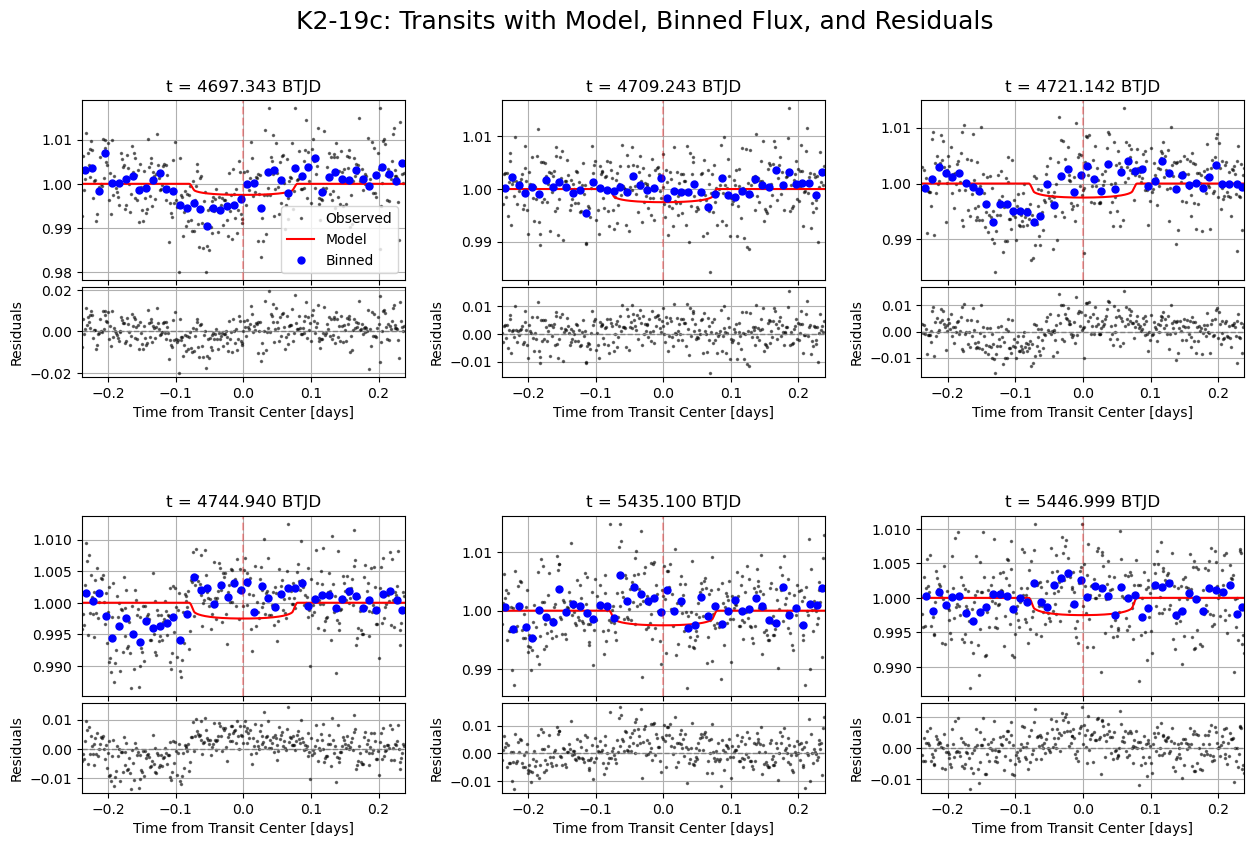

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import batman

# --- Light curve and transit parameters ---
# Ephemeris and lightcurve (assuming already loaded)
time = convert_time_t2p(lc.time.value)
flux = lc.flux

# Transit model parameters (update with your values!)
Tc_c = 2456853.0007 - 2457000
t0 = convert_time_t2p(Tc_c)       # BTJD
P_c = 11.8993   # days
T14_c = 3.823  * 0.0416667  # days
rp_c = 0.0458
b_c = 0.17
q1_c = 0.4
q2_c = 0.3


# Model setup template
def make_model(t_center, time_segment):
    params = batman.TransitParams()
    params.t0 = t_center
    params.per = P_c
    params.rp = rp_c
    params.b = b_c
    params.T14 = T14_c
    params.u = [2 * np.sqrt(q1_c) * q2_c, np.sqrt(q1_c) * (1 - 2 * q2_c)]
    params.limb_dark = "quadratic"
    m = batman.TransitModel(params, time_segment)
    return m.light_curve(params)

# --- Compute expected transits ---
epoch_start = int(np.floor((time.min() - t0) / P_c))
epoch_end = int(np.ceil((time.max() - t0) / P_c))
epochs = np.arange(epoch_start, epoch_end + 1)
transit_times = t0 + epochs * P_c

# --- Collect segments ---
chunks = []
for t_center in transit_times:
    mask = np.abs(time - t_center) < (T14_c * 1.5)
    if np.any(mask):
        t_seg = time[mask]
        f_seg = flux[mask]
        model_flux = make_model(t_center, t_seg)
        residuals = f_seg - model_flux
        dt = t_seg - t_center
        chunks.append((dt, f_seg, model_flux, residuals, t_center))

# --- Plotting layout ---
n = len(chunks)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig = plt.figure(figsize=(5 * ncols, 3 * nrows * 1.5))
outer = gridspec.GridSpec(nrows, ncols, wspace=0.3, hspace=0.5)

for i, (dt, f, model, res, t_center) in enumerate(chunks):
    row = i // ncols
    col = i % ncols
    inner = gridspec.GridSpecFromSubplotSpec(2, 1,
        subplot_spec=outer[row, col], height_ratios=[2, 1], hspace=0.05)

    # Top: flux and model
    ax_flux = plt.Subplot(fig, inner[0])
    ax_flux.plot(dt, f, 'k.', alpha=0.5, markersize=3, label='Observed')
    ax_flux.plot(dt, model, 'r-', lw=1.5, label='Model')

    # Bin and overlay binned points
    dt_bin, f_bin = bin_data(dt, f, binsize=0.01)  # bin size in days
    ax_flux.plot(dt_bin, f_bin, 'bo', markersize=5, label='Binned')

    ax_flux.axvline(0, color='red', linestyle='--', alpha=0.3)
    ax_flux.set_xlim(-T14_c*1.5, T14_c*1.5)
    ax_flux.set_title(f"t = {t_center:.3f} BTJD")
    ax_flux.tick_params(labelbottom=False)
    ax_flux.grid(True)
    if i == 0:
        ax_flux.legend(loc='best')
    fig.add_subplot(ax_flux)

    # Bottom: residuals
    ax_resid = plt.Subplot(fig, inner[1])
    ax_resid.plot(dt, res, 'k.', alpha=0.5, markersize=3)
    ax_resid.axhline(0, color='gray', linestyle='--', lw=1)
    ax_resid.set_xlim(-T14_c*1.5, T14_c*1.5)
    ax_resid.set_xlabel("Time from Transit Center [days]")
    ax_resid.set_ylabel("Residuals")
    ax_resid.grid(True)
    fig.add_subplot(ax_resid)

fig.suptitle("K2-19c: Transits with Model, Binned Flux, and Residuals", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_15405/613366923.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


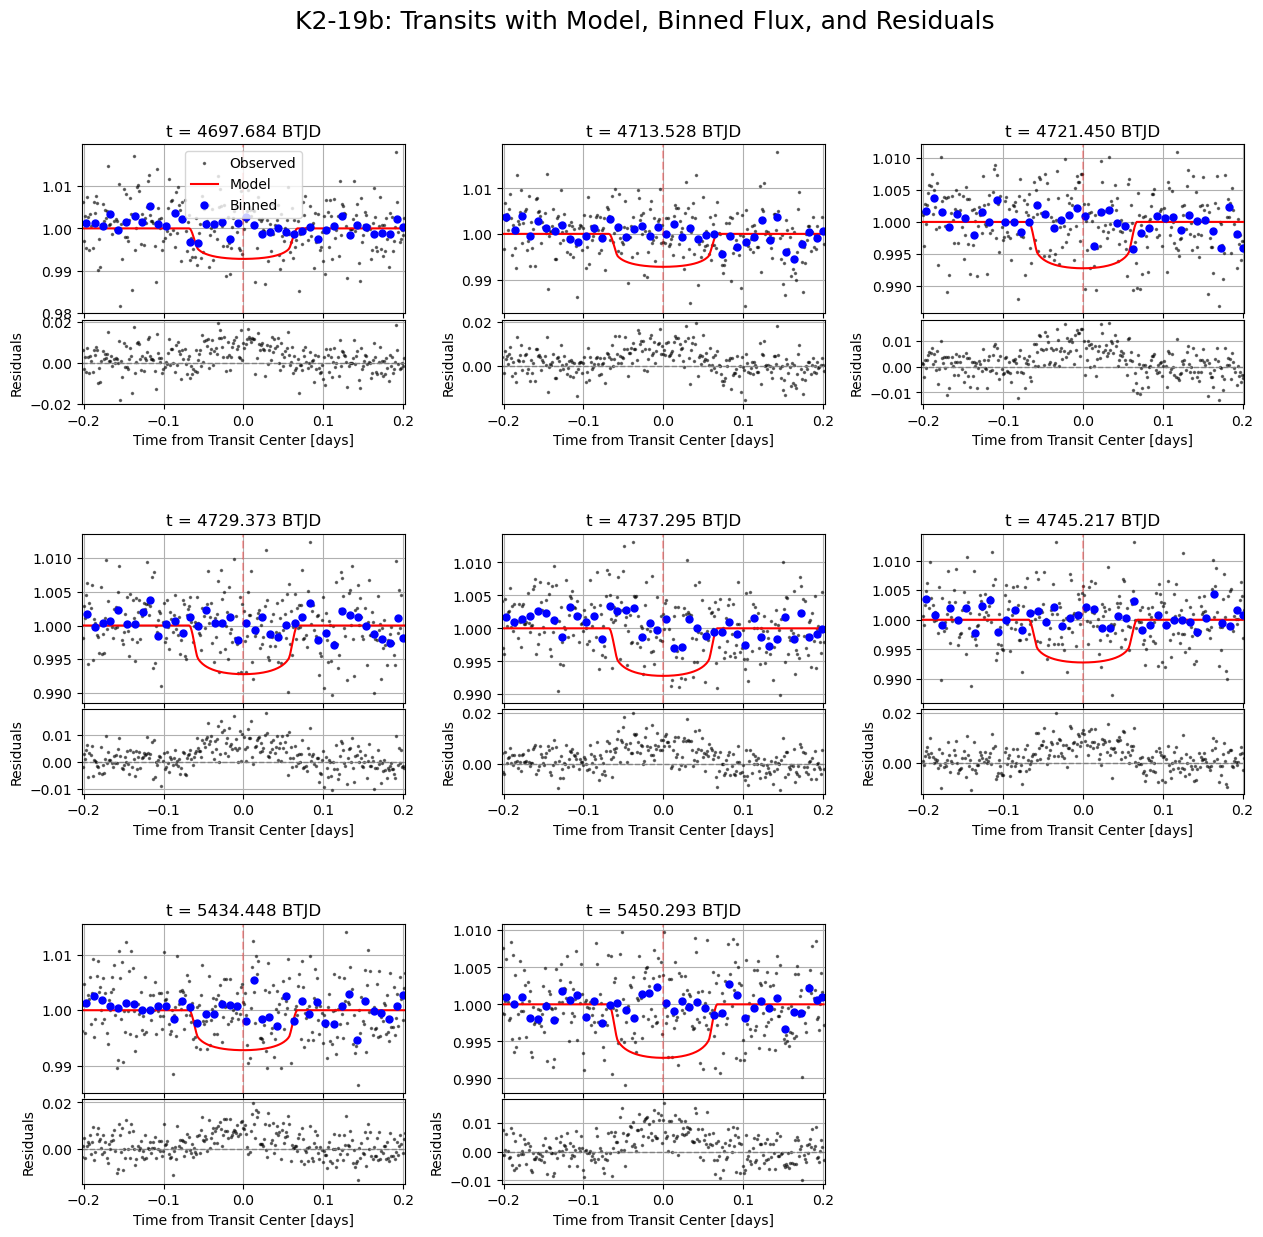

In [78]:
# Ephemeris and lightcurve (assuming already loaded)
time = convert_time_t2p(lc.time.value)
flux = lc.flux

# Transit model parameters (update with your values!)
Tc_b = 2456860.9023 - 2457000
t0 = convert_time_t2p(Tc_b)       # BTJD
P_b = 7.9222    # days
T14_b = 3.237  * 0.0416667  # days
rp_b = 0.0777
b_b = 0.17
q1_b = 0.4
q2_b = 0.3



# Model setup template
def make_model(t_center, time_segment):
    params = batman.TransitParams()
    params.t0 = t_center
    params.per = P_b
    params.rp = rp_b
    params.b = b_b
    params.T14 = T14_b
    params.u = [2 * np.sqrt(q1_b) * q2_b, np.sqrt(q1_b) * (1 - 2 * q2_b)]
    params.limb_dark = "quadratic"
    m = batman.TransitModel(params, time_segment)
    return m.light_curve(params)




# --- Compute expected transits ---
epoch_start = int(np.floor((time.min() - t0) / P_b))
epoch_end = int(np.ceil((time.max() - t0) / P_b))
epochs = np.arange(epoch_start, epoch_end + 1)
transit_times = t0 + epochs * P_b

# --- Collect segments ---
chunks = []
for t_center in transit_times:
    mask = np.abs(time - t_center) < (T14_b * 1.5)
    if np.any(mask):
        t_seg = time[mask]
        f_seg = flux[mask]
        model_flux = make_model(t_center, t_seg)
        residuals = f_seg - model_flux
        dt = t_seg - t_center
        chunks.append((dt, f_seg, model_flux, residuals, t_center))

# --- Plotting layout ---
n = len(chunks)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig = plt.figure(figsize=(5 * ncols, 3 * nrows * 1.5))
outer = gridspec.GridSpec(nrows, ncols, wspace=0.3, hspace=0.5)

for i, (dt, f, model, res, t_center) in enumerate(chunks):
    row = i // ncols
    col = i % ncols
    inner = gridspec.GridSpecFromSubplotSpec(2, 1,
        subplot_spec=outer[row, col], height_ratios=[2, 1], hspace=0.05)

    # Top: flux and model
    ax_flux = plt.Subplot(fig, inner[0])
    ax_flux.plot(dt, f, 'k.', alpha=0.5, markersize=3, label='Observed')
    ax_flux.plot(dt, model, 'r-', lw=1.5, label='Model')

    # Bin and overlay binned points
    dt_bin, f_bin = bin_data(dt, f, binsize=0.01)  # bin size in days
    ax_flux.plot(dt_bin, f_bin, 'bo', markersize=5, label='Binned')

    ax_flux.axvline(0, color='red', linestyle='--', alpha=0.3)
    ax_flux.set_xlim(-T14_b*1.5, T14_b*1.5)
    ax_flux.set_title(f"t = {t_center:.3f} BTJD")
    ax_flux.tick_params(labelbottom=False)
    ax_flux.grid(True)
    if i == 0:
        ax_flux.legend(loc='best')
    fig.add_subplot(ax_flux)

    # Bottom: residuals
    ax_resid = plt.Subplot(fig, inner[1])
    ax_resid.plot(dt, res, 'k.', alpha=0.5, markersize=3)
    ax_resid.axhline(0, color='gray', linestyle='--', lw=1)
    ax_resid.set_xlim(-T14_b*1.5, T14_b*1.5)
    ax_resid.set_xlabel("Time from Transit Center [days]")
    ax_resid.set_ylabel("Residuals")
    ax_resid.grid(True)
    fig.add_subplot(ax_resid)

fig.suptitle("K2-19b: Transits with Model, Binned Flux, and Residuals", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# TESS Transit Times

In [22]:
from scipy.optimize import minimize
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from scipy.optimize import curve_fit

In [23]:
### read table from Petigura et al. 2020
file = "ajab5220t1_mrt.txt"
def read_table(file_name):
    ### path to table - Petigura et al 2020
    file_path = os.path.join(data_dir, file_name)

    ### Define the column names 
    columns = ["Planet", "Transit", "Inst", "Tc", "e_Tc", "Source"]

    ### Read the text file, specifying space as the delimiter, skipping model_guess_omc rows
    df = pd.read_csv(file_path, delim_whitespace=True, skiprows=22, names=columns)

    ### Remove NaN values
    df = df.dropna()
    return df

df = read_table(file)

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_69768/3528285165.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, skiprows=22, names=columns)


In [24]:
### params from exoplanet archive
per_b = 7.9222
rp_b = 0.0777
T14_b = 3.237 * 0.0416667  # convert to days
b_b = 0.17
q1_b = 0.4
q2_b = 0.3

### Get lightcurve data from TESS

In [25]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

In [26]:
### Download the light curve data
lc = lk.search_lightcurve("K2-19",author = 'SPOC').download_all()
lc = lc.stitch()
if mask_transits == True:
    ### mask transit times before flattening
    #transit_times = [4697.28834658, 4713.12428017, 4721.03972171, 4728.96021376, 4736.88070581, 4744.79614735, 5433.87895563, 5449.71993973]
    transit_times = [4697.28834658, 4713.12933068, 4721.03972171, 4728.96021376, 4736.88070581, 4744.80119786, 5433.87895563, 5449.71993973]
    masked_lc = lc

    times = convert_time_t2p(masked_lc.time.value)

    ### Initialize a mask with all False values (i.e., include all data points initially)
    mask = np.zeros_like(times, dtype=bool)

    ### Iterate through each transit time and update the mask
    for transit_time in transit_times:
        mask |= (times > (transit_time - T14_b/2)) & (times < (transit_time + T14_b/2))

    ### Flatten the masked light curve
    masked_lc = masked_lc.flatten(window_length=901, mask=mask).remove_outliers()
    lc = masked_lc
else:
    ### flatten unmasked lightcurve 
    lc = lc.flatten(window_length=901).remove_outliers()

### Fit for transit times

In [27]:
### initialize guess times (using BLS ephem)
transit_num = [0,2,3,4,5,6,93,95]

tc_guess=[]
for num in transit_num:
    t = tc_b_bls + (num * period_b_bls)
    tc_guess.append(t)

### data from lightcurve 
time_tess = np.array(lc.time.value)
flux=np.array(lc.flux)
flux_err = np.array(lc.flux_err)

time = convert_time_t2p(time_tess)
tc_guess = convert_time_t2p(np.array(tc_guess))
tc_guess = np.array(tc_guess)
print(f'TC guess(TESS): {tc_guess}')

TC guess(TESS): [4697.28077082 4713.12175491 4721.04224696 4728.96273901 4736.88323106
 4744.80372311 5433.88653139 5449.72751549]


In [28]:
### get tc ranges for fit
tc = []
for i in range(len(tc_guess)):
    start = tc_guess[i] - ttv_hour
    end = tc_guess[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc.append(t)

In [29]:
### initialize arrays
tc_chi = np.zeros(len(tc))
tc_chi_parabola = np.zeros(len(tc))
ttv = np.zeros(len(tc))
ttv_p = np.zeros(len(tc))
errors = []
errors_p = []

In [30]:
def omc(obs_time, t_num, p, tc):
    calc_time = tc + (t_num* p)
    omc = obs_time - calc_time
    return omc#*24 #days to hours

### Find the intersection points
def intersection_func(t): #masked
    return np.interp(t, tc1, chi_sq) - err_threshold

In [31]:
### plot X^2 vs tc for each guess
for j in range(len(tc)):
    tc1 = tc[j]
    chi_sq = np.zeros(len(tc1))
    chi_sq_lc = np.zeros(len(tc1))
    for i in range(len(tc1)):
        t0_b = 	tc1[i]
        theta_initial = [t0_b, per_b, rp_b, b_b, T14_b, q1_b, q2_b]
        
        ### initialize params
        params = batman.TransitParams()
        params.t0, params.per, params.rp,params.b, params.T14, q1, q2 = theta_initial
        params.u = [2*np.sqrt(q1)*q2, np.sqrt(q1)*(1-2*q2)]  # Limb darkening coefficients
        params.limb_dark = 'quadratic'
        
        ### mask data - extract relevant photometry
        start = tc_guess[j] - ttv_hour
        end = tc_guess[j] + ttv_hour
        mask = (time > (start)) & (time < (end))
        
        transit_model = batman.TransitModel(params, time[mask])
            
        # Generate model light curve
        model_flux = transit_model.light_curve(params)
        
        # Calculate chi-squared value
        sigma2 = flux_err[mask] 
        chi_squared = np.sum(((flux[mask] - model_flux) / sigma2)**2)
        chi_sq[i] = (chi_squared)

    ### masked
    min_chi_time = tc1[np.argmin(chi_sq)]
    min_chi = chi_sq.min()

    tc_chi[j] = min_chi_time
    idx = transit_num[j]
    ttv[j] = min_chi_time - tc_guess[j]

    chi_mask = (chi_sq <= min_chi + 3)
    fit_mask = (chi_sq <= min_chi + 1)

    ### fit parabola to the chisq
    p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)  

    ### Extract the coefficients   y = ax^2 + bx + c
    a_chi_sq, b_chi_sq, c_chi_sq = p_chi_sq
    
    ### Find the minimum of the parabola xmin = -b/2a from taking derivative=0
    tc_best_fit = -b_chi_sq / (2 * a_chi_sq)
    
    ### Calculate the minimum chi-squared value
    chi_sq_min = a_chi_sq * tc_best_fit**2 + b_chi_sq * tc_best_fit + c_chi_sq
    tc_chi_parabola[j] = tc_best_fit

    ### Calculate the parabola best fit 
    p_1 = a_chi_sq*tc1**2 + b_chi_sq*tc1 + c_chi_sq

    ### calculate ttv from parabola fit 
    ttv_p[j] = tc_best_fit - tc_guess[j]

    ### delta chisq = 1 gives errors
    err_threshold = min_chi + 1 # using chisq discrete minimum
    err_threshold_p = chi_sq_min + 1 # using minimum of parabola
  
    # Find the intersection using root_scalar
    intersections = []
    for k in range(len(tc1) - 1):
        if (chi_sq[k] - err_threshold) * (chi_sq[k + 1] - err_threshold) < 0:
            sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]])
            if sol.converged:
                intersections.append((sol.root - min_chi_time))
    errors.append(intersections)

    intersections_p = []
    for k in range(len(tc1) - 1):
        if (p_1[k] - err_threshold_p) * (p_1[k + 1] - err_threshold_p) < 0:
            sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]])
            if sol.converged:
                intersections_p.append((sol.root - tc_best_fit))
    errors_p.append(intersections_p)

    # plt.plot(tc1[chi_mask], chi_sq[chi_mask],label='chisq')
    # plt.plot(tc1[chi_mask], p_1[chi_mask],label='chisq parabola', color='orange')
    # plt.axvline(x=tc_guess[j], color='r', linestyle='--', label='Bls Guess')
    # plt.axvline(x=min_chi_time, linestyle='--', label='Chisq min')
    # plt.axvline(x=tc1[np.argmin(p_1)], color='orange', linestyle='--', label='Chisq min parabola')

    # # for inter in intersections:
    # #     plt.axvline(x=inter, color='blue', linestyle='--')
    # plt.axhline(y=err_threshold, color='green', linestyle='--', label='Error Threshold')
    # plt.title(f'Transit {j+1}: Planet b')
    # plt.xlabel('tc')
    # plt.ylabel('X^2')
    # plt.legend()
    # plt.show()

In [32]:
#avg the errors   sig^2 = 0.5(sig1^2 + sig2^2)
err_tc_chi = []
for i in range(len(errors)):
    sig = np.sqrt(errors[i][0]**2 + errors[i][1]**2)
    err_tc_chi.append(sig)

err_tc_chi_p = []
for i in range(len(errors_p)):
    sig = np.sqrt(errors_p[i][0]**2 + errors_p[i][1]**2)
    err_tc_chi_p.append(sig)

### Saving Results

In [33]:
# Initialize empty list for storing results
results = []

# Loop through the transits and collect the data dynamically
for j in range(len(tc)):
    transit = transit_num[j]
    transit_time = tc_chi[j]
    avg_error = err_tc_chi[j]
    ttv_value = ttv[j]
    transit_time_parabola = tc_chi_parabola[j]
    avg_error_parabola = err_tc_chi_p[j]
    ttv_value_parabola = ttv_p[j]
    
    # Create a dictionary for the current row
    row = {
        'Planet': 'k2-19b',
        'Transit': transit,
        'Tc(TESS)': transit_time,
        'Tc_err': avg_error,
        'TTV(TESS)': ttv_value,
        'Tc(TESS) Parabola': transit_time_parabola,
        'Tc_err Parabola': avg_error_parabola,
        'TTV(TESS) Parabola': ttv_value_parabola,
        'Time Offset': 'BJD - 2454833',
        'Period': period_b_bls,
        'Tc_offset': tc_b_bls
    }

    # Append the row to the results list
    results.append(row)

# After the loop, create a DataFrame from the results list
tess_transit_data = pd.DataFrame(results)

# Save the DataFrame to a file named 'tess_times.csv'
tess_transit_data.to_csv('tess_transit_data.csv', index=False)

# Print the DataFrame to see the collected data
print(tess_transit_data)

   Planet  Transit     Tc(TESS)    Tc_err  TTV(TESS)  Tc(TESS) Parabola  \
0  k2-19b        0  4697.289029  0.004384   0.008258        4697.288910   
1  k2-19b        2  4713.127344  0.002837   0.005589        4713.127453   
2  k2-19b        3  4721.041830  0.003013  -0.000417        4721.041738   
3  k2-19b        4  4728.959653  0.002993  -0.003086        4728.959826   
4  k2-19b        5  4736.880812  0.004142  -0.002419        4736.880952   
5  k2-19b        6  4744.798635  0.002808  -0.005088        4744.798760   
6  k2-19b       93  5433.878774  0.003929  -0.007758        5433.878892   
7  k2-19b       95  5449.720258  0.002277  -0.007257        5449.720286   

   Tc_err Parabola  TTV(TESS) Parabola    Time Offset    Period  \
0         0.004375            0.008139  BJD - 2454833  7.920492   
1         0.002829            0.005698  BJD - 2454833  7.920492   
2         0.003008           -0.000509  BJD - 2454833  7.920492   
3         0.002976           -0.002913  BJD - 2454833  7